Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from lstm_unet import lstm_unet
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_13300\4067212722.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = "AR")


333
torch.Size([1, 800])


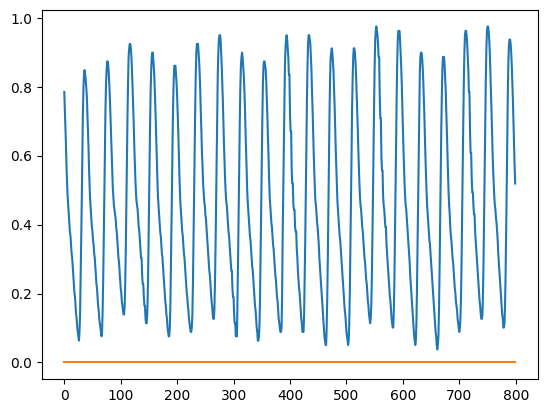

[800, 400, 200, 100, 50]
[[[100, 64], [64, 128], [128, 256], [256, 512]], [3, 3, 3, 3], [1.0, 1.0, 1.0, 1.0]]
[[512, 512], 3, 1.0]
[[[1024, 256], [512, 128], [256, 64], [128, 1]], [3, 3, 3, 3], [1.0, 1.0, 1.0, 1.0]]
[[10, 10, 10, 10], [2, 2, 2, 2], [4.0, 4.0, 4.0, 4.0]]
[[6, 6, 6, 6], [2, 2, 2, 2], [2.0, 2.0, 2.0, 2.0]]


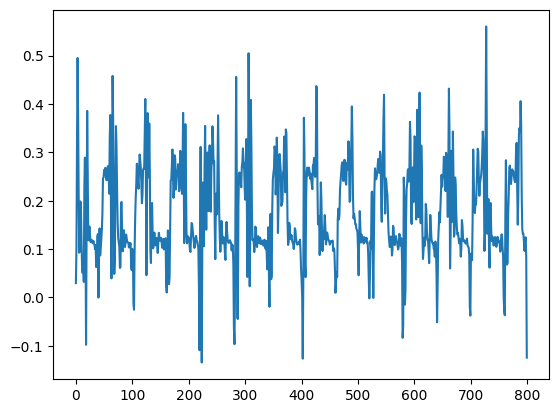

In [2]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = "AR")
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

import torch.nn.functional as F

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
            "Input size":           1,
            "Hidden size":          100,
            "Number layers":        2,
            "Encoder structure":    [100,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,1],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [10,10,10,10],
            "Kernel decoder":       [6,6,6,6],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model1 = lstm_unet(para = para)
model1.structure_calculate(True)
y = model1(dataset[1][0].unsqueeze(1))
plt.plot(y.cpu().detach().numpy().flatten())

plt.show()

Training

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {"Serie length":         800,
            "Input size":           1,
            "Hidden size":          100,
            "Number layers":        2,
            "Encoder structure":    [100,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,1],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Kernel encoder":       [8,8,8,8],
            "Kernel decoder":       [4,4,4,4],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Sigmoid()
    }

model = lstm_unet(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=1500,batch=64,visualize=1)

True
Iteration: 1/1500. loss_train: 0.5297446250915527. loss_val: 0
Iteration: 2/1500. loss_train: 0.5234999060630798. loss_val: 0
Iteration: 3/1500. loss_train: 0.5230743885040283. loss_val: 0
Iteration: 4/1500. loss_train: 0.5232478976249695. loss_val: 0
Iteration: 5/1500. loss_train: 0.5233662724494934. loss_val: 0
Iteration: 6/1500. loss_train: 0.5168043375015259. loss_val: 0
Iteration: 7/1500. loss_train: 0.5145927667617798. loss_val: 0
Iteration: 8/1500. loss_train: 0.5189014077186584. loss_val: 0
Iteration: 9/1500. loss_train: 0.5154661536216736. loss_val: 0
Iteration: 10/1500. loss_train: 0.5138552188873291. loss_val: 0
Iteration: 11/1500. loss_train: 0.5071433186531067. loss_val: 0
Iteration: 12/1500. loss_train: 0.5100226402282715. loss_val: 0
Iteration: 13/1500. loss_train: 0.5121979713439941. loss_val: 0
Iteration: 14/1500. loss_train: 0.5094919800758362. loss_val: 0
Iteration: 15/1500. loss_train: 0.5076811909675598. loss_val: 0
Iteration: 16/1500. loss_train: 0.5066327452

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_13300\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  0.7014221
Mean loss:  0.053487483
Min loss:  0.009153519
Number of test:  84


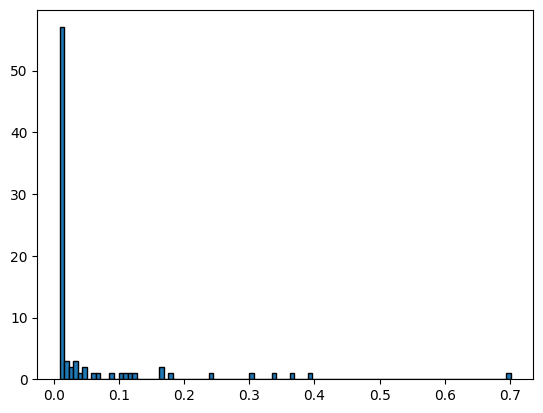

0.1647326


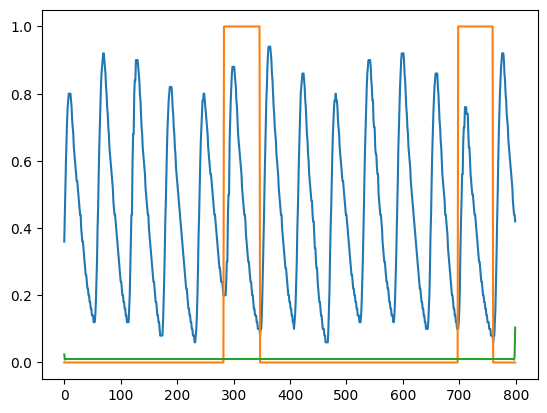

0.009154581


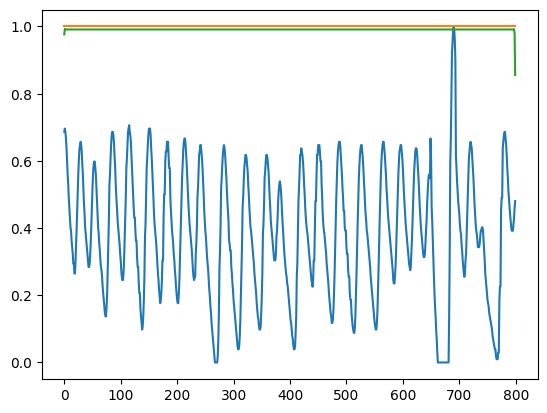

0.009154396


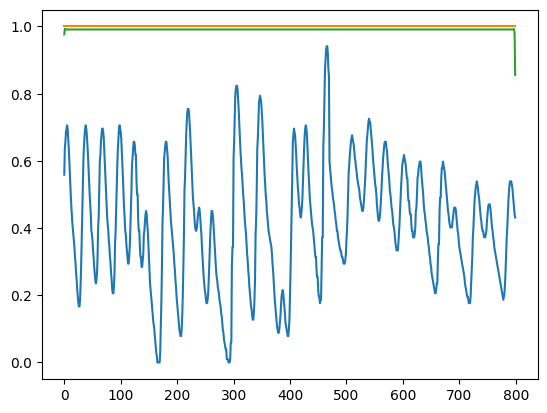

0.010482601


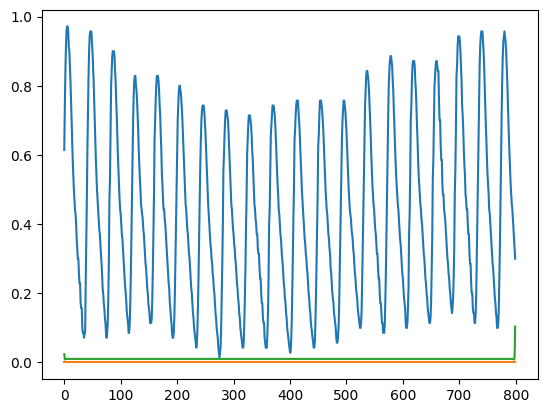

0.010481668


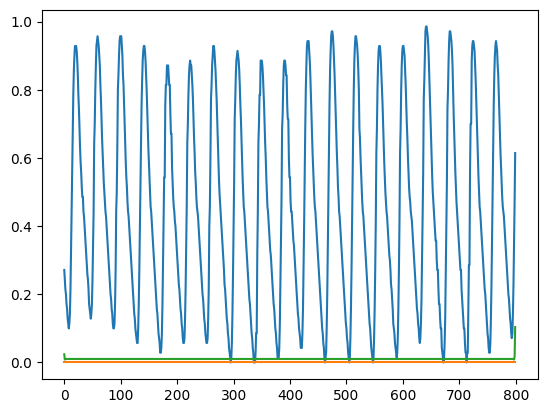

0.010481515


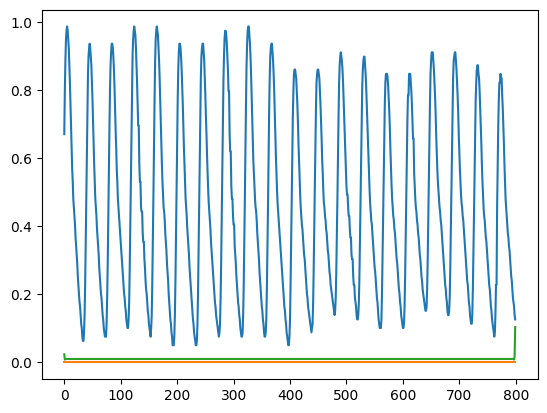

0.010482622


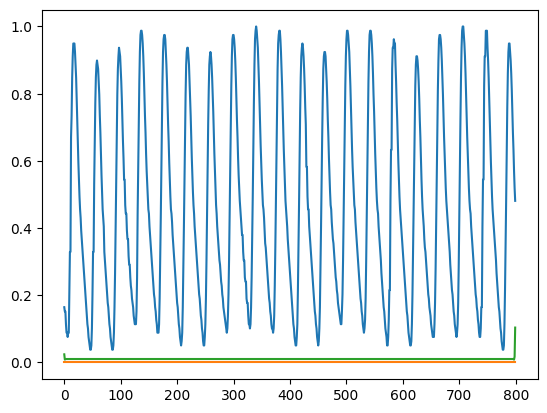

0.010497968


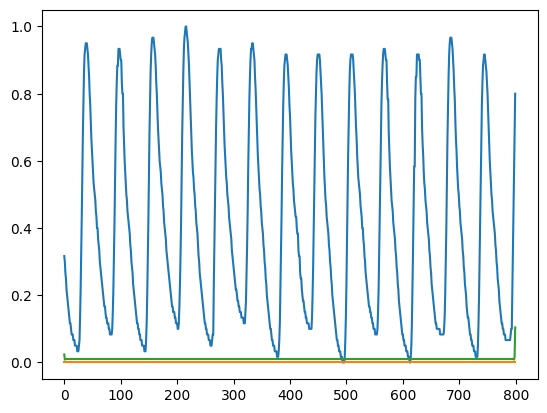

0.010497873


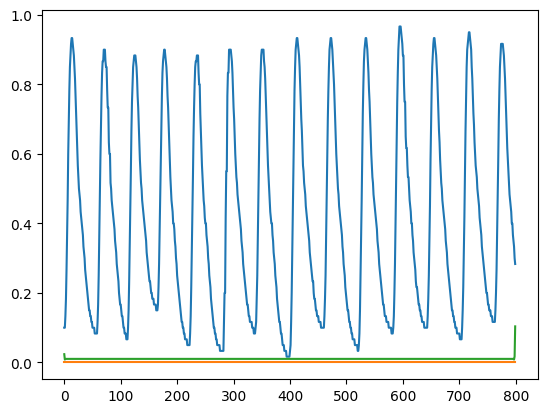

0.010484457


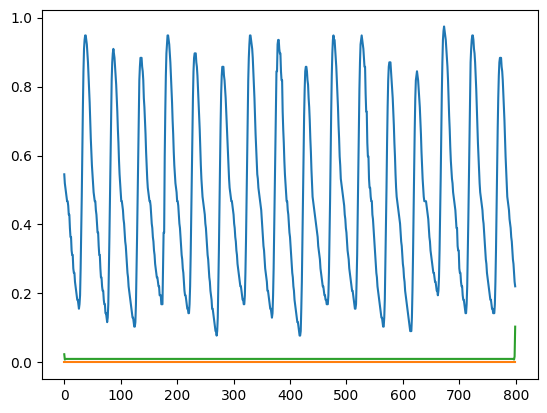

0.0104963835


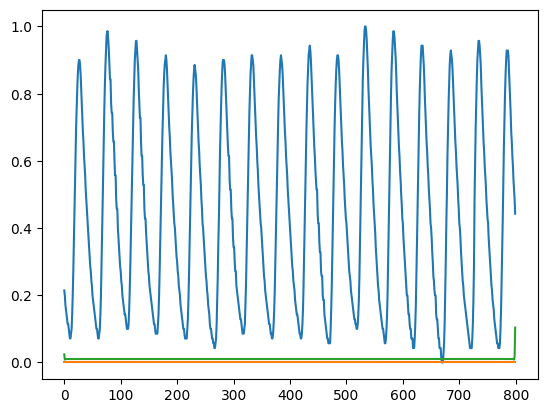

0.010539576


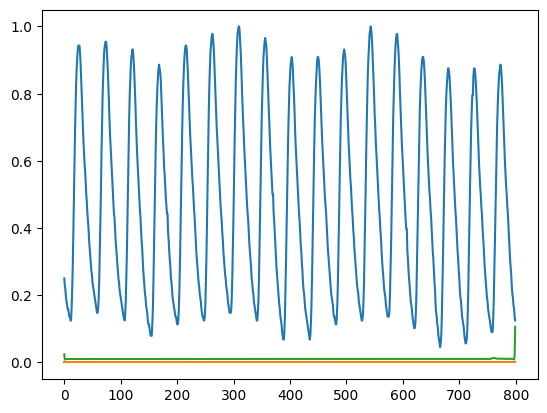

0.015093886


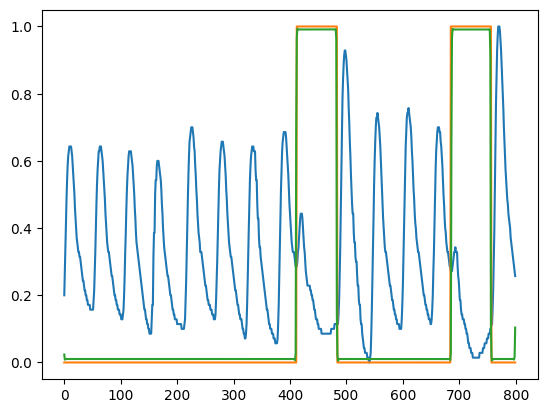

0.010825982


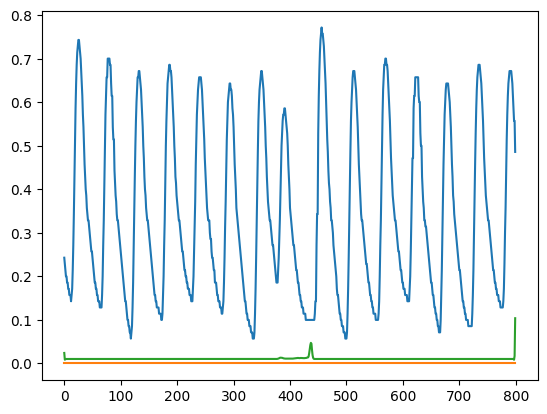

0.011197453


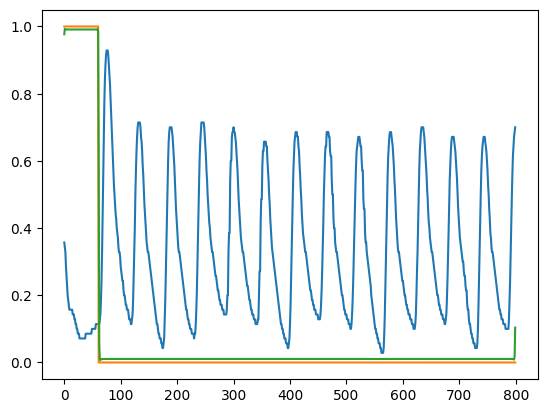

0.010488272


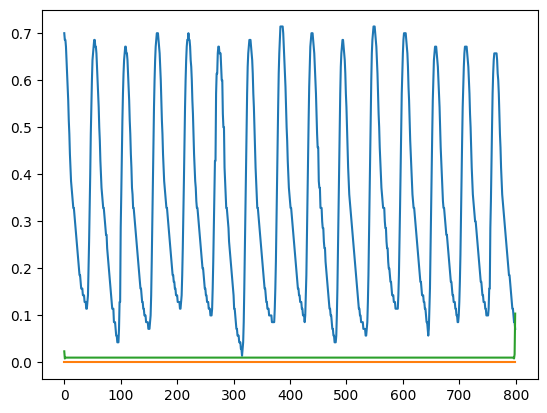

0.010345517


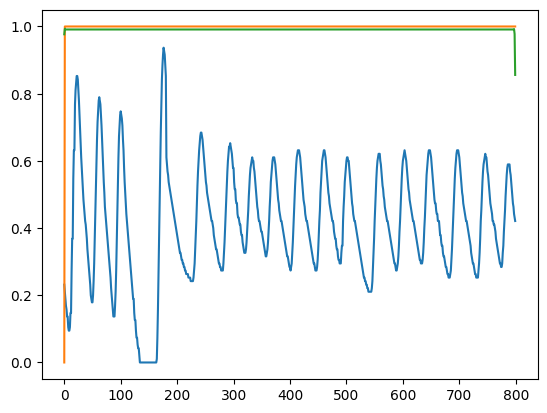

0.009153519


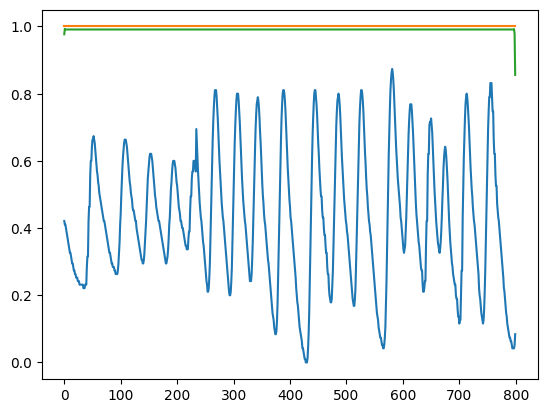

0.009153525


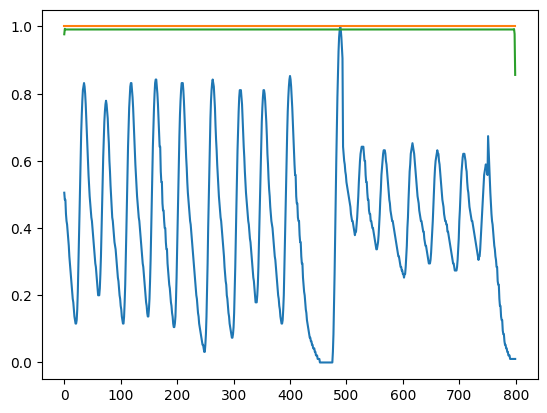

0.11261921


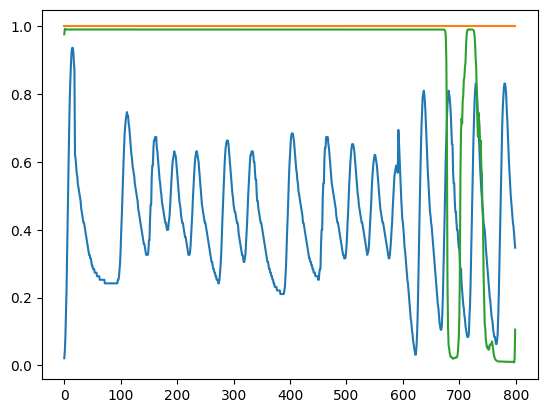

0.0091536725


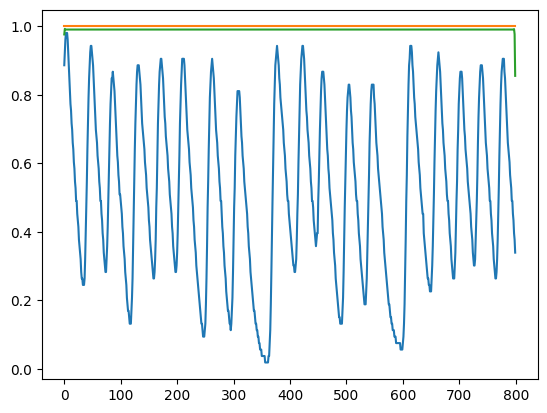

0.010500948


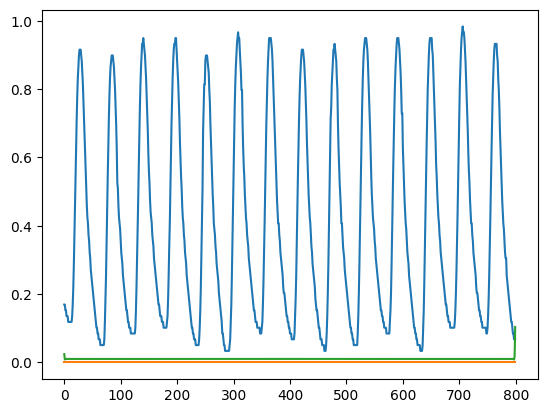

0.010498534


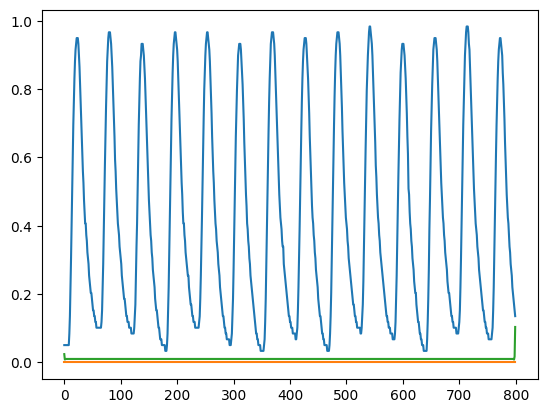

0.010496111


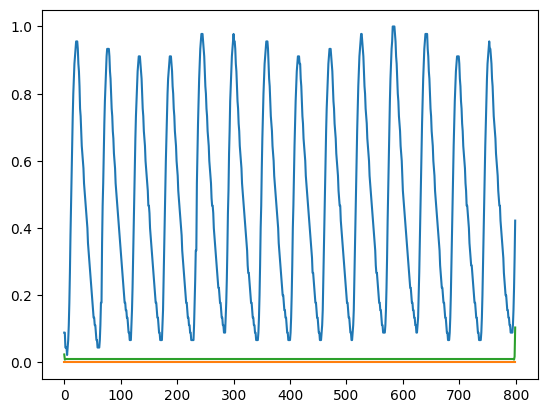

0.010490622


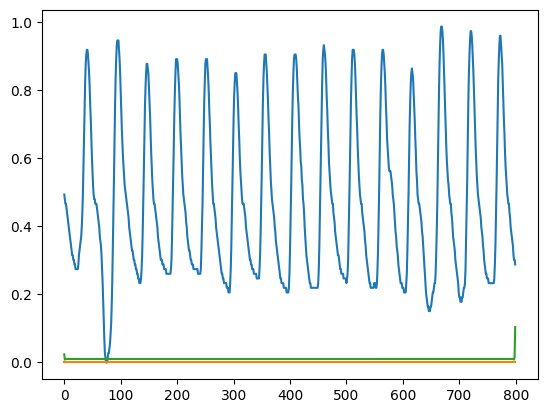

0.01048382


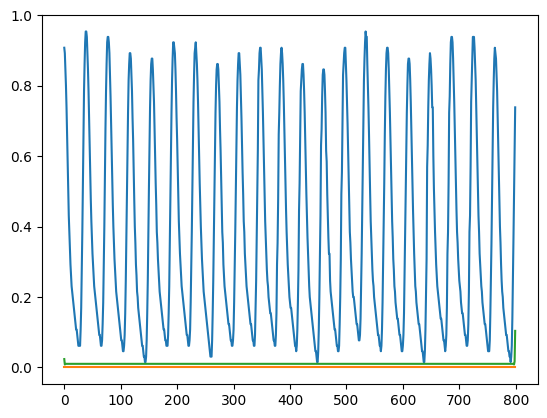

0.043866728


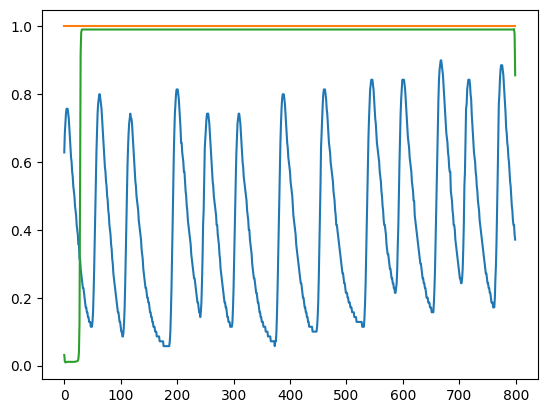

0.010484323


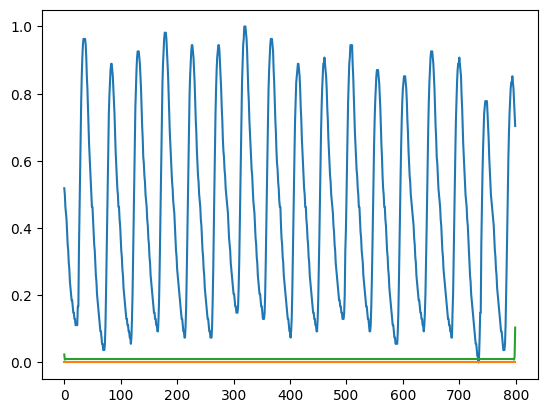

0.010483713


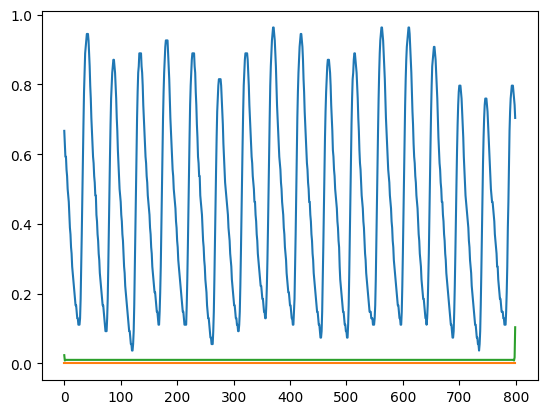

0.3942897


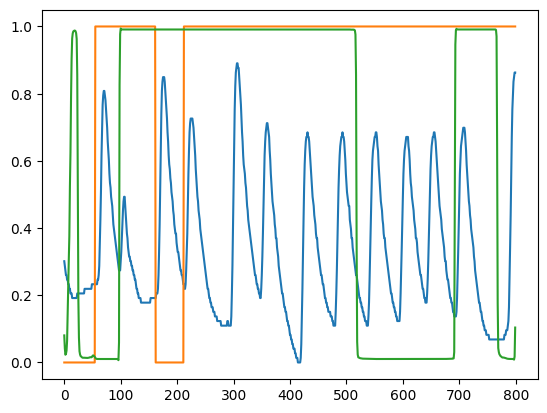

0.010491426


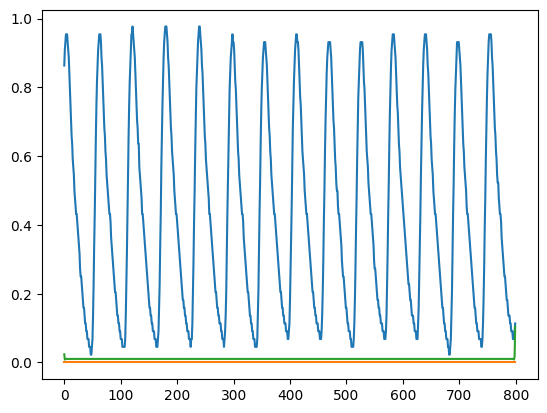

0.010487914


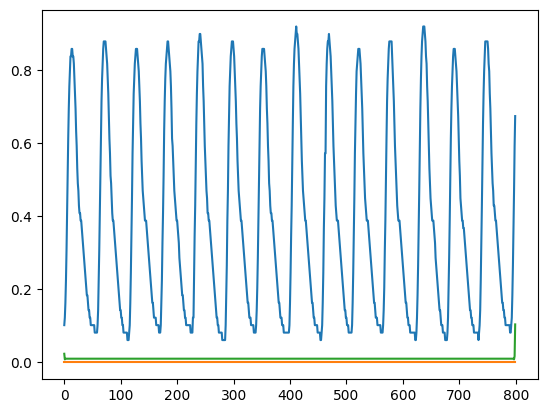

0.010480784


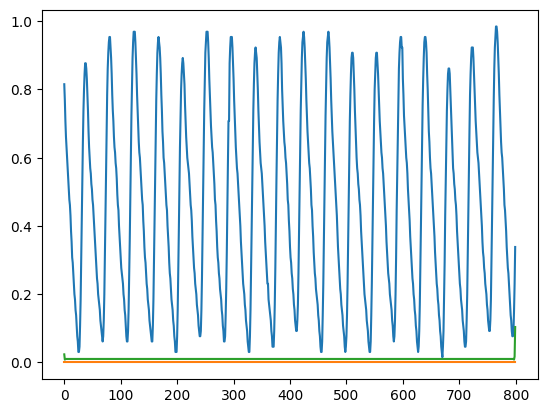

0.010485186


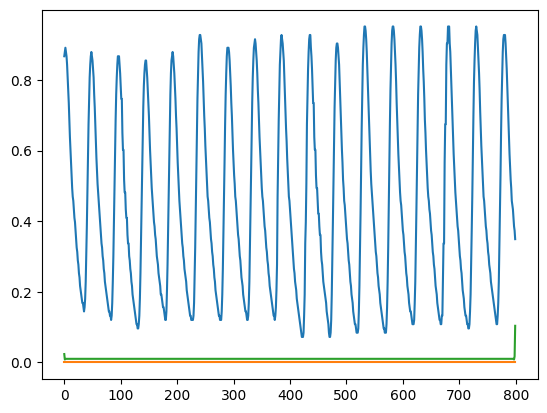

0.010485848


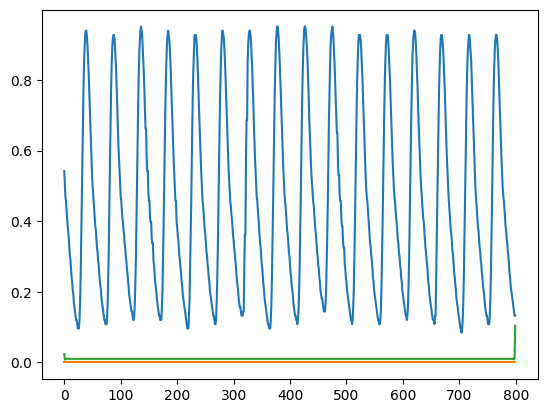

0.010482248


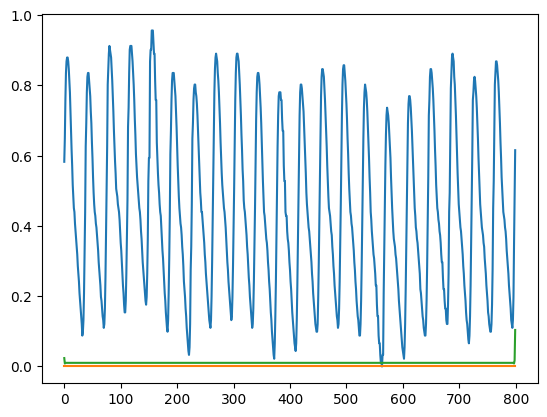

0.010483148


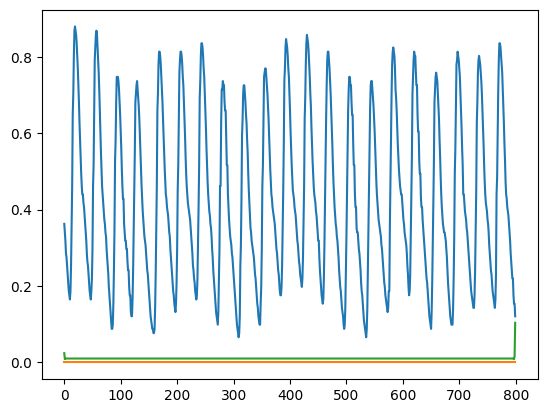

0.010482227


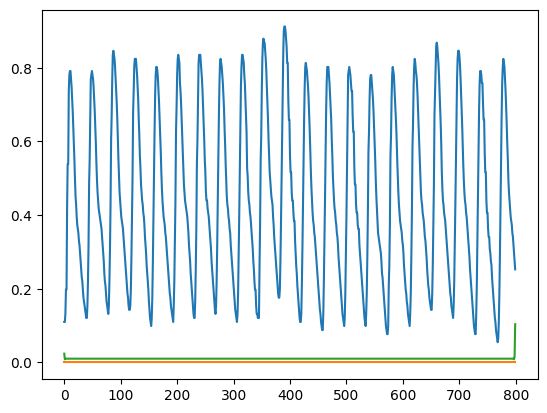

0.010494382


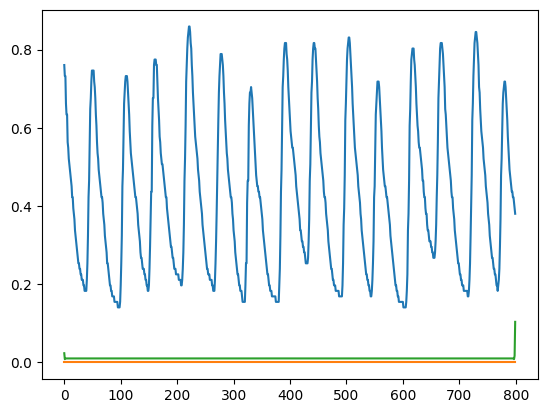

0.010345393


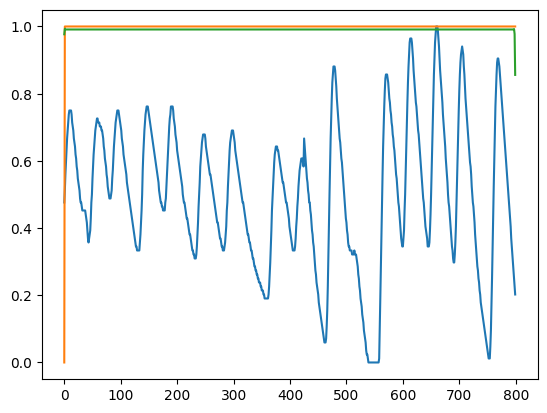

0.010503361


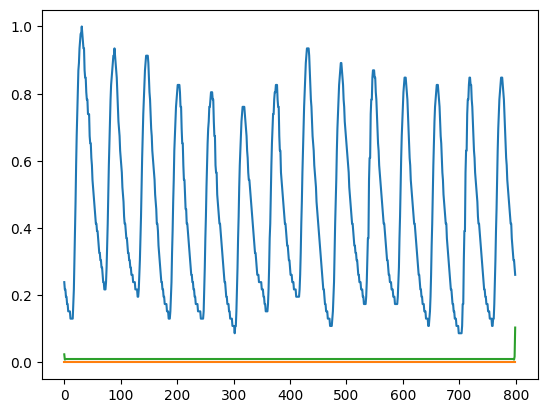

0.009153545


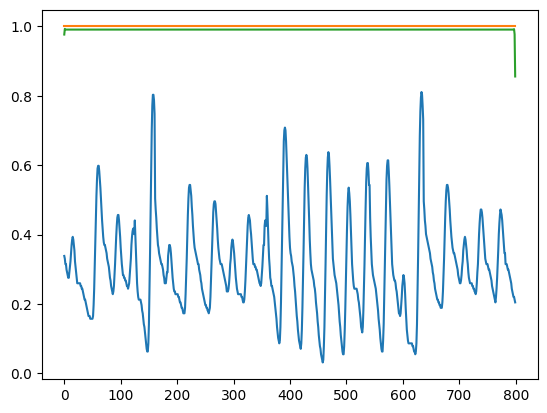

0.022367608


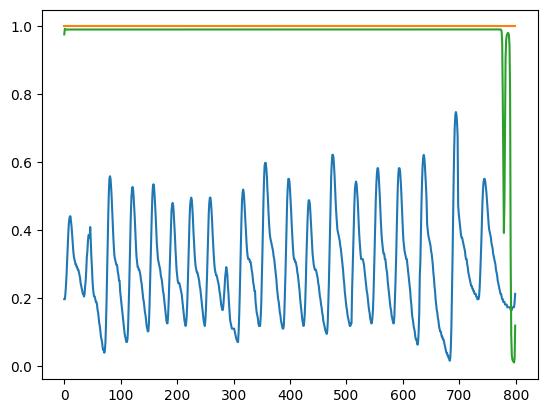

0.010486245


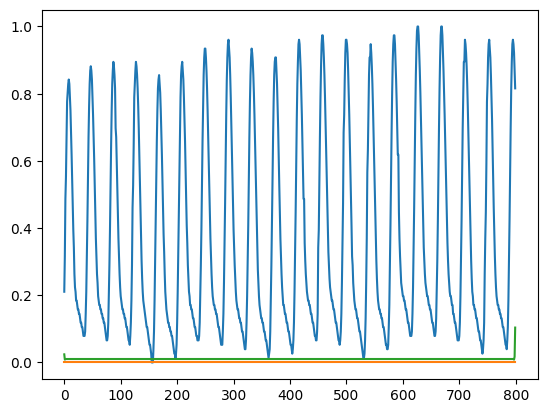

0.012237434


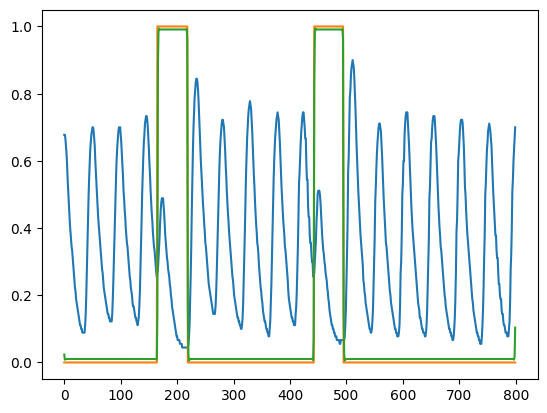

0.058217116


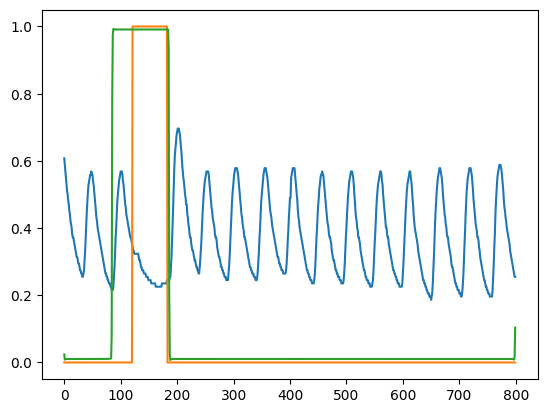

0.011756075


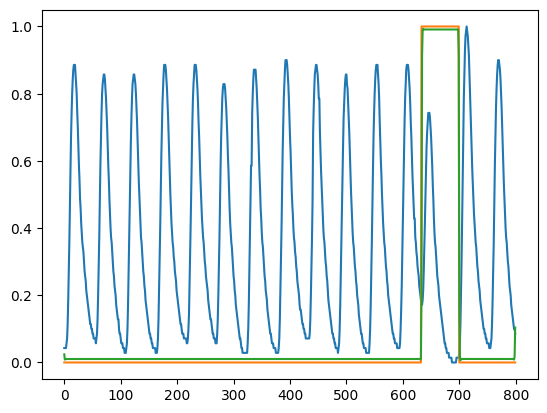

0.031150982


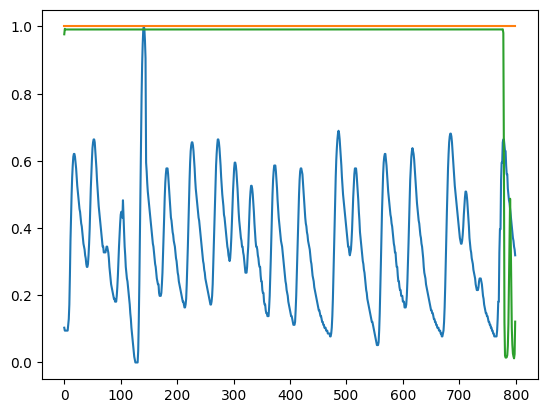

0.0091541065


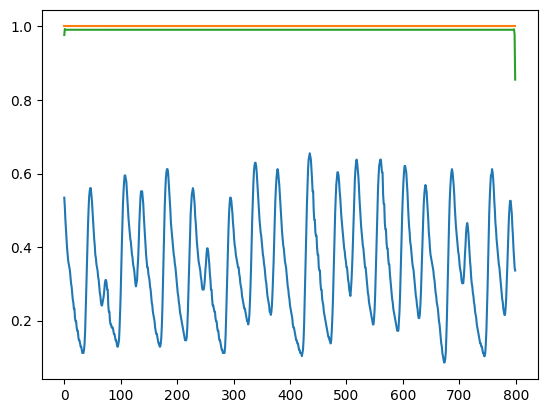

0.030183248


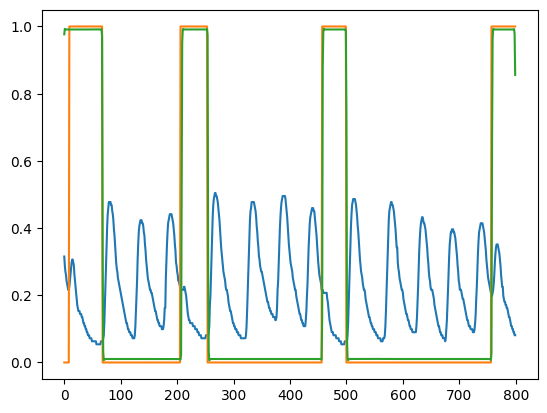

0.040792447


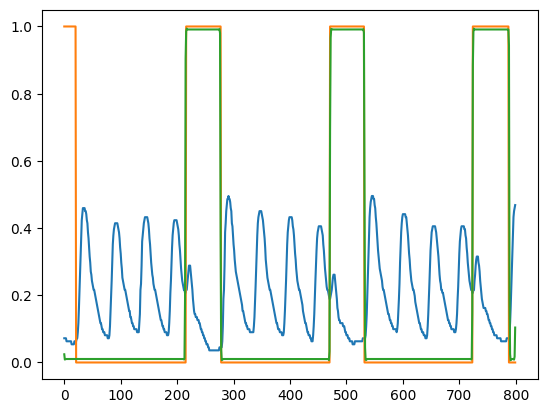

0.17830093


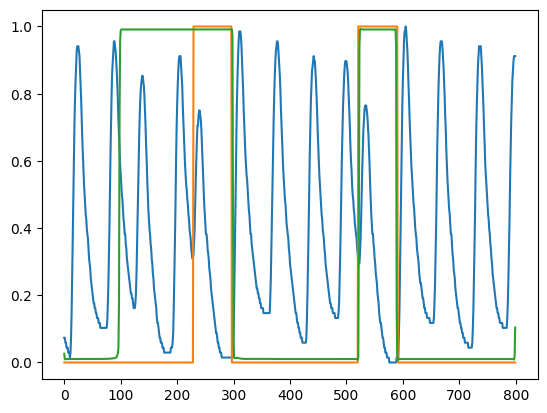

0.010493976


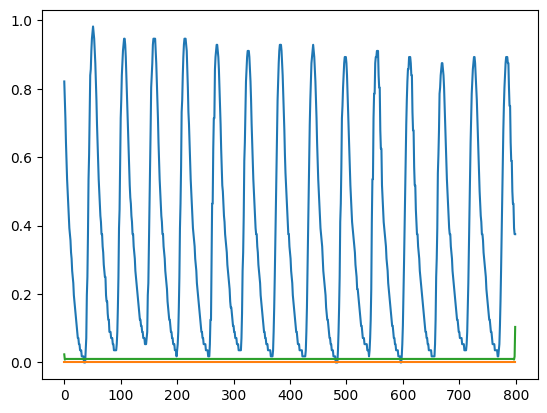

0.010482678


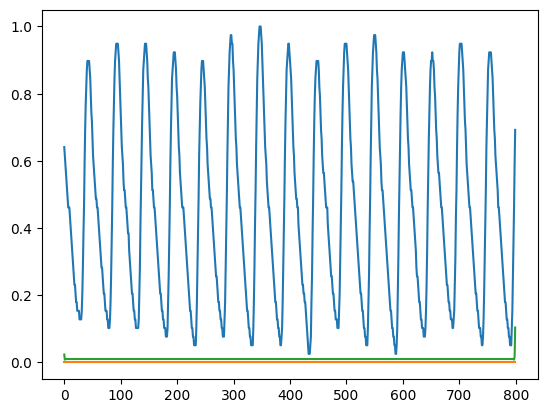

0.010489243


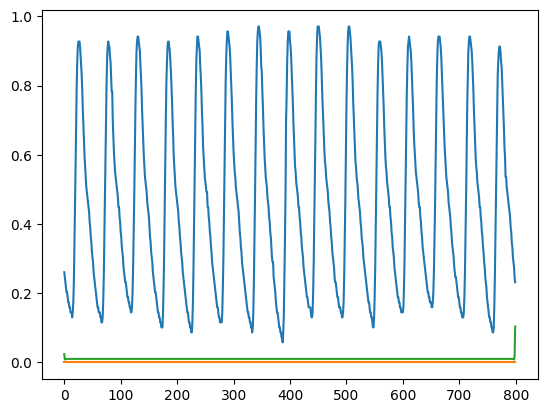

0.02073948


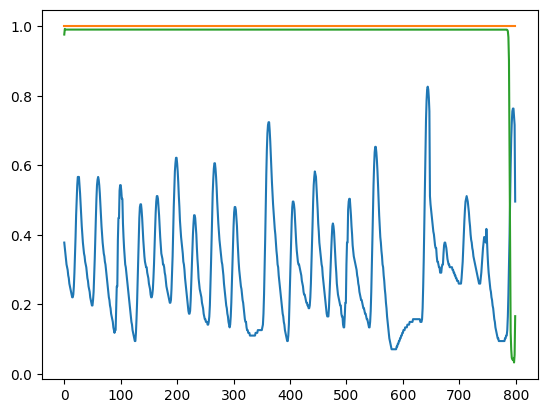

0.009153534


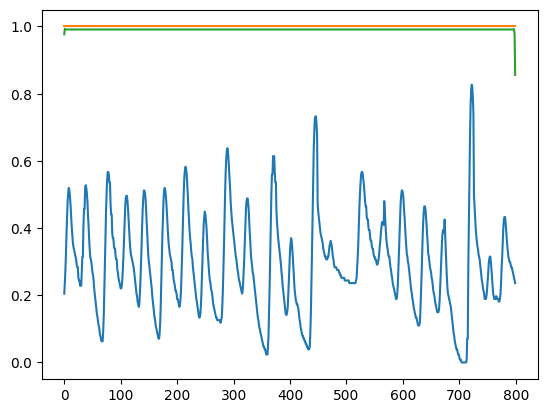

0.014299509


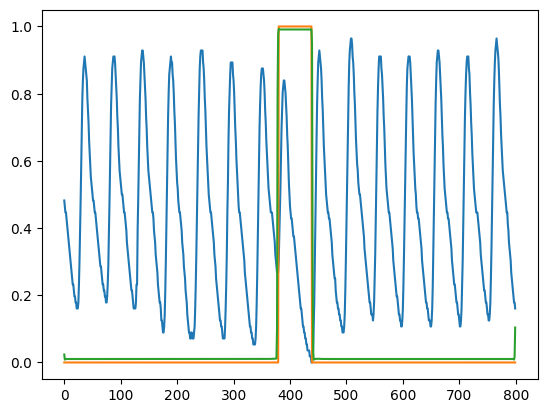

0.009153615


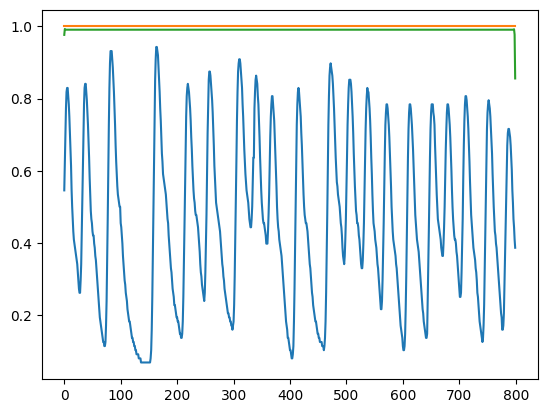

0.034037374


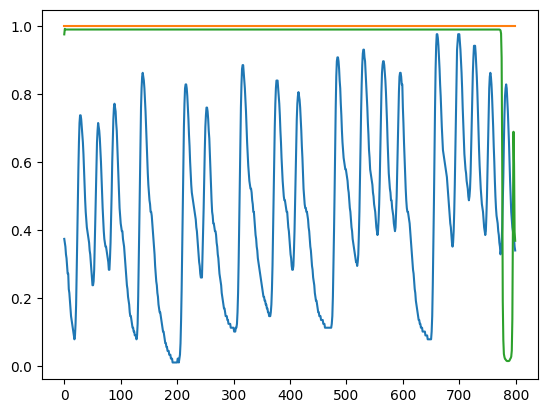

0.009153683


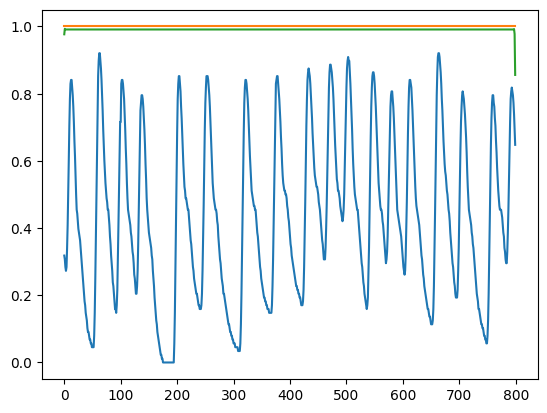

0.12541747


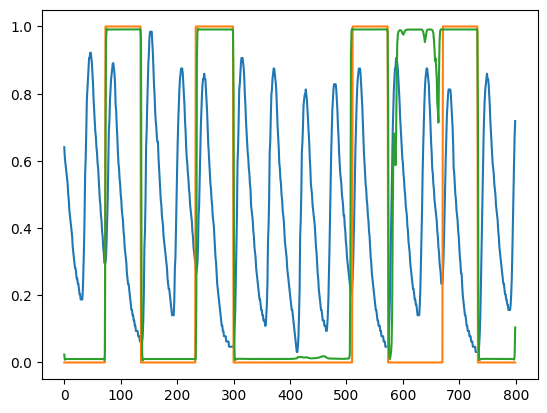

0.34069785


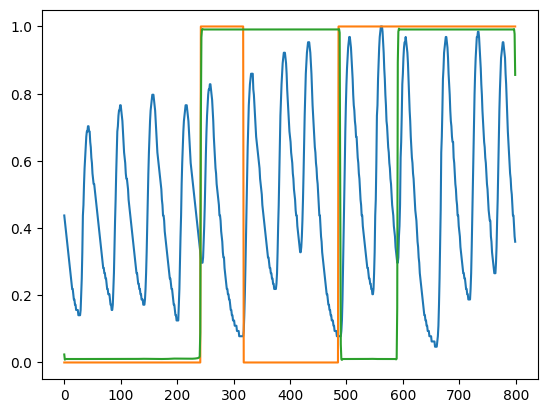

0.36246628


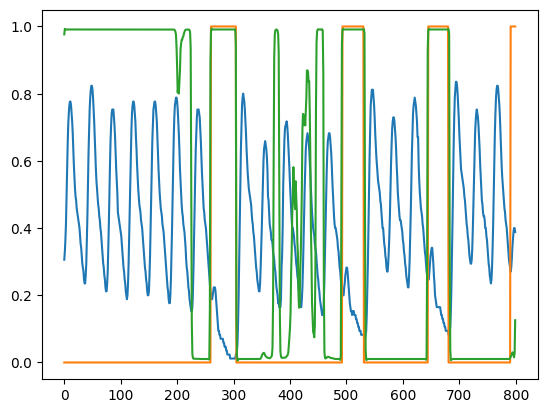

0.7014221


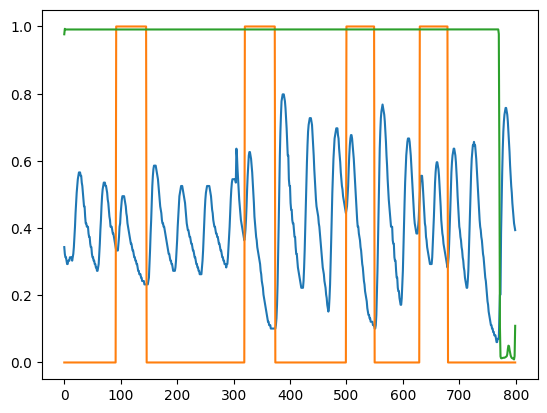

0.010491963


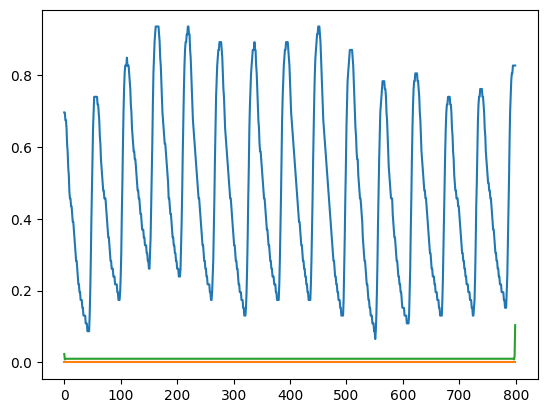

0.16827409


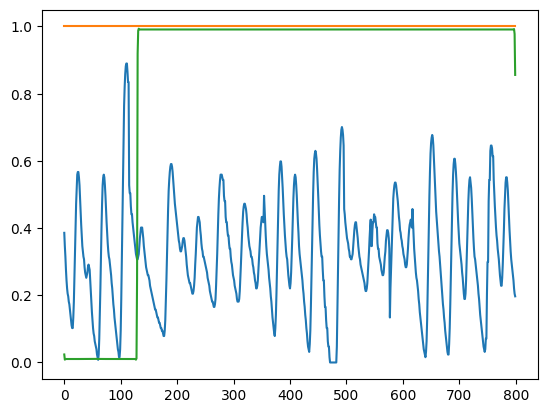

0.11918004


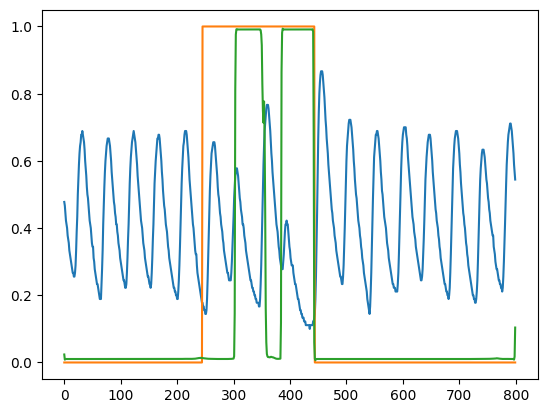

0.30487454


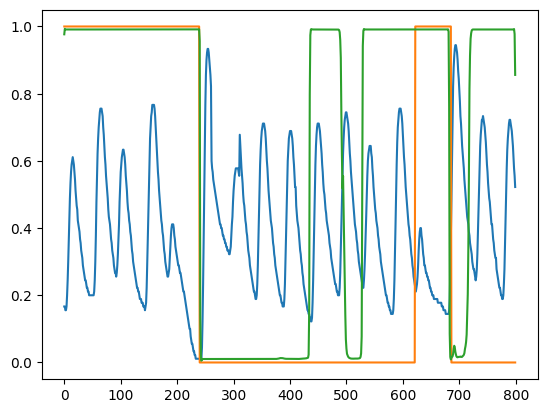

0.015357279


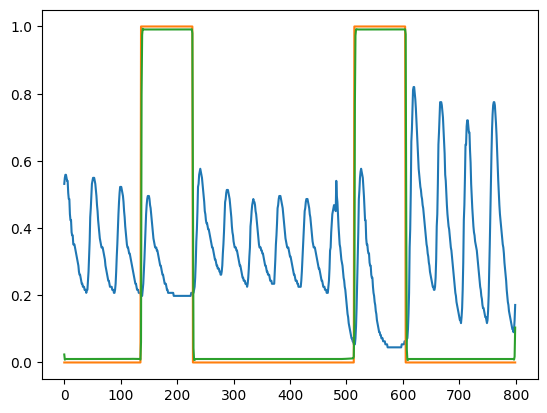

0.01497256


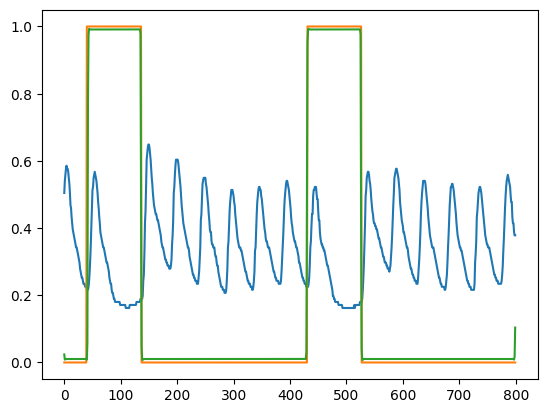

0.01796602


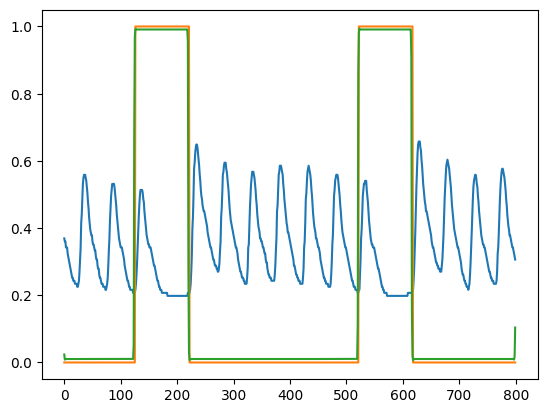

0.015641183


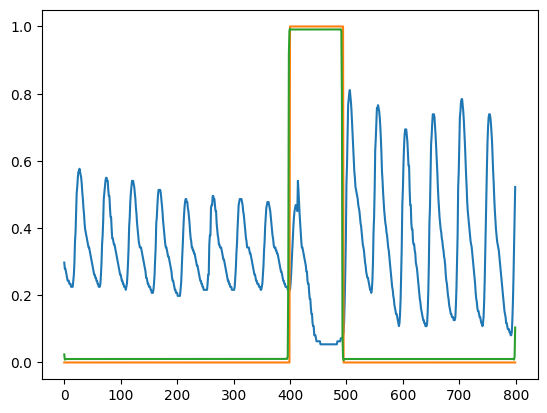

0.023412056


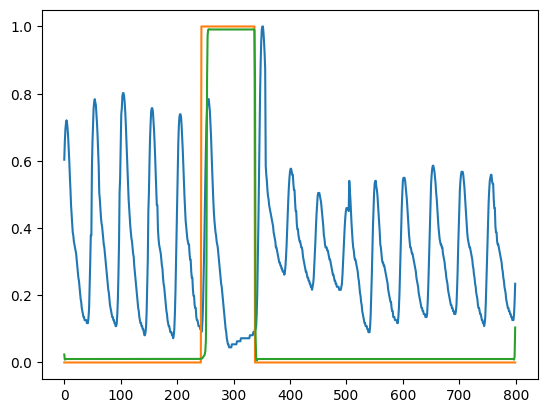

0.10213001


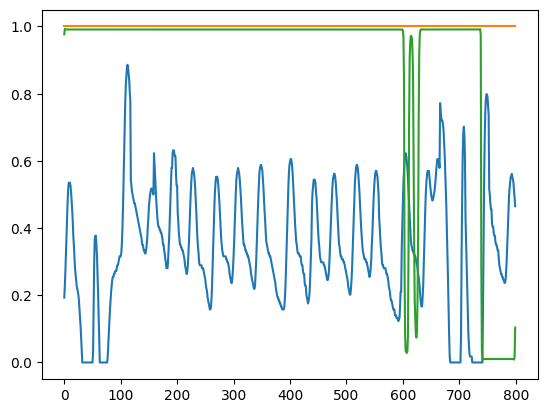

0.009153588


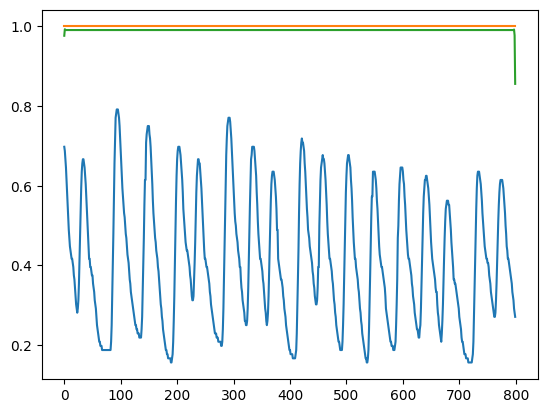

0.09166515


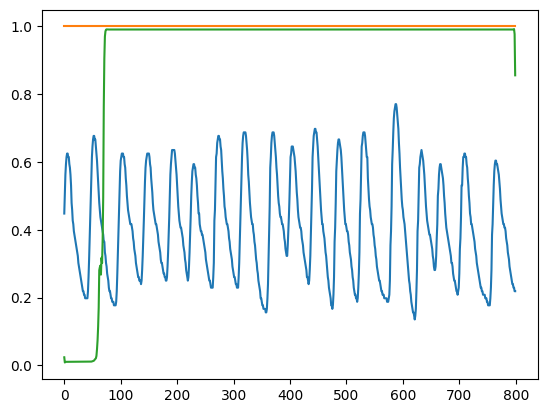

0.049568422


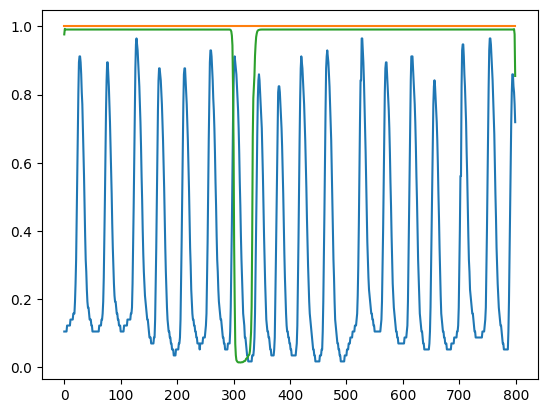

0.07020342


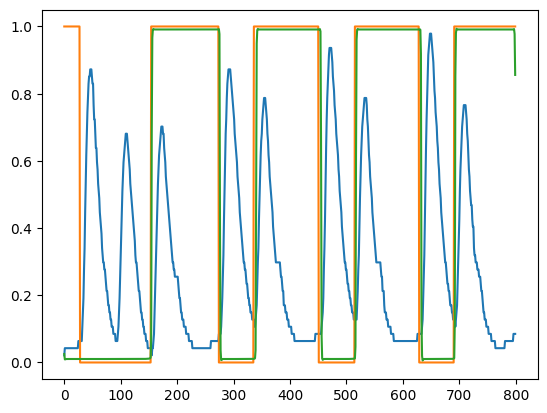

0.24364778


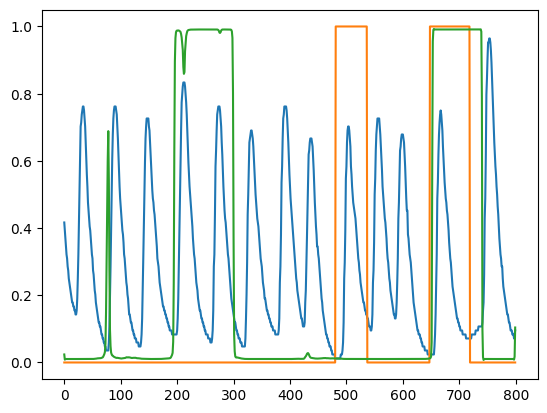

0.009153583


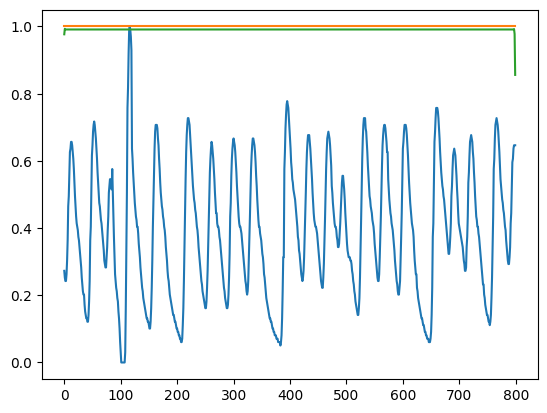

0.009153595


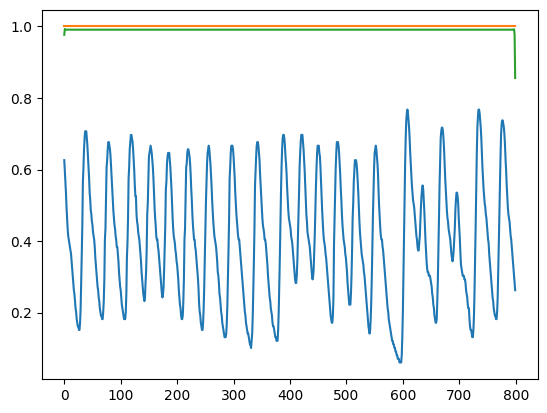

0.015153131


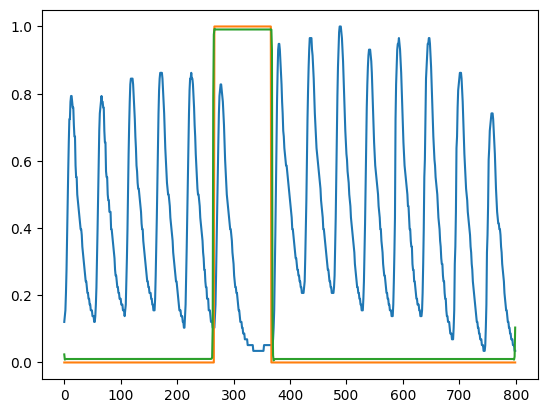

0.028810391


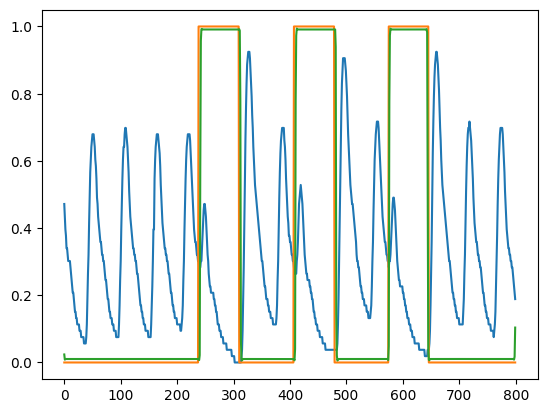

In [4]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()